In this work, I developed a reinforcement learning framework based on Q-learning to find optimal actuation gaits for microswimmers, to make them
propel effeciently over large distances in the low Reynolds number regime
which is described by Stokes Equation.

In [1]:
import numpy as np
import random

Parameters

In [2]:
# Total spheres - n
# Total arms    - n-1
# Total states  - (2**(n-1))
# Total actions - (2*(n-1)) BUT for each state, n-1 actions are possible.
# So Q - Matrix - (Rows = 2**(n-1), Columns = 2*(n-1)), also note that the half of the entries should exactly be zero.

In [3]:
n = 10 # number of spheres

# Displacement finding:

In [4]:
import numpy as np
from itertools import product

# STATES

States = {} # each state is defined by arm length connecting all micro swimmers

all_states = list(product([6, 10], repeat=n-1))

for i, s in enumerate(all_states):
    States[i+1] = s

# ACTIONS

Actions = {} # each action is defined by the indexed arm to either extend or contract by magnitude = 4

action_id = 1

for k in range(n-1):

    # extend kth arm
    action = np.zeros(n-1, dtype=int)
    action[k] = +4
    Actions[action_id] = tuple(action)
    action_id += 1

    # contract kth arm
    action = np.zeros(n-1, dtype=int)
    action[k] = -4
    Actions[action_id] = tuple(action)
    action_id += 1

# OSEEN FORCE CALCULATOR

## Doing calculation for Stokesian fluids

def oseen_n_force_calculator(state , action , number_of_spheres):

    r = 1
    u = 1

    n = number_of_spheres

    H = np.zeros((n,n),dtype=np.float64)

    dist_values = np.zeros((n-1))

    for k in range(n-1):

        if state[k] == +1:
            dist_values[k] = 10
        else:
            dist_values[k] = 6

    # Oseen Tensor

    for i in range(n):

        for j in range(n):

            if i == j:

                H[i,j] = 1/(6*np.pi*r*u)

            else:

                separation = np.sum(
                    dist_values[min(i,j):max(i,j)]
                )

                H[i,j] = (
                    1/(4*np.pi*u*separation)
                )

    # Force Solver

    b = np.zeros((n))
    A = np.zeros((n,n),dtype=np.float64)

    for i in range(n-1):

        A[i,:] = H[i+1,:] - H[i,:]

        if i == action-1:

            # extend if contracted
            if dist_values[i] == 6:
                b[i] = +4

            # contract if extended
            else:
                b[i] = -4

    A[-1,:] = 1.0

    F = np.linalg.solve(A,b)

    return H,F


# NET DISPLACEMENT

def net_disp_finder(state, action):

    t_sphere = len(state) + 1

    H,F = oseen_n_force_calculator(
        state,
        action,
        t_sphere
    )

    v = H @ F

    disp_ = np.mean(v)

    return disp_


# VALID ACTIONS

##  At each state we define the valid action sets. Not all actions are possible for given state

valid_actions = {}

for state_id, state in States.items():

    allowed = []

    for action_id, action in Actions.items():

        new_state = tuple(
            state[i] + int(action[i])
            for i in range(n-1)
        )

        if all(x in [10,6] for x in new_state):
            allowed.append(action_id)

    valid_actions[state_id] = allowed

# TRANSITION DICTIONARY

transition = {} # at given state s, we take action a, and it leads to new state s'

# reverse lookup
state_to_id = {
    v:k for k,v in States.items()
}

for state_id, state in States.items():

    transition[state_id] = {}

    for action_id, action in Actions.items():

        if action_id in valid_actions[state_id]:

            new_state = tuple(
                state[i] + int(action[i])
                for i in range(n-1)
            )

            next_state_id = state_to_id[new_state]

            transition[state_id][action_id] = next_state_id

        else:

            transition[state_id][action_id] = None

# REWARD DICTIONARY

'''Here we consider the rewards as the net displacement of the middle sphere in one step.
For given state s, taking action a, will lead to reward r '''

rewards = {}

for state_id, state in States.items():

    rewards[state_id] = {}

    for action_id in valid_actions[state_id]:

        # which arm is moving?
        arm_number = (
            np.nonzero(Actions[action_id])[0][0]
        ) + 1

        state_pn = [+1 if e == 10 else -1 for e in state]
        reward = net_disp_finder(
            np.array(state_pn),
            arm_number
        )

        rewards[state_id][action_id] = reward

# PRINT


# print("States:\n")
# print(States)

# print("\nActions:\n")
# print(Actions)

# print("\nValid Actions:\n")
# print(valid_actions)

# print("\nTransition:\n")
# print(transition)

# print("\nRewards:\n")
# print(rewards)

INITIALIZING Q-MATRIX

In [5]:
# Initialize Q - Matrix with random_numbers:
num_states = 2**(n - 1)
num_actions = 2*(n - 1)

In [6]:
np.random.seed(100)

q_matrix = np.random.rand(
    num_states,
    num_actions
)

# Masking:

for state_id in States:

    allowed = valid_actions[state_id]

    for action_id in range(1, num_actions+1):

        if action_id not in allowed:

            q_matrix[
                state_id-1,
                action_id-1
            ] = -np.inf

print(q_matrix)

[[0.54340494       -inf 0.42451759 ...       -inf 0.81168315       -inf]
 [0.81622475       -inf 0.43170418 ...       -inf       -inf 0.89041156]
 [0.98092086       -inf 0.89054594 ... 0.88485329 0.35950784       -inf]
 ...
 [      -inf 0.35663319       -inf ...       -inf       -inf 0.39983763]
 [      -inf 0.42965565       -inf ... 0.4394811  0.972821         -inf]
 [      -inf 0.32340562       -inf ... 0.41065553       -inf 0.81832578]]


In [7]:
q_matrix.shape

(512, 18)

In [8]:
# Datas for plotting :

cumulative_disp = 0
disp_history = []
i = 0

cycle_disp = 0
cycle_hist = []

In [9]:
# This code basically find the cycle present in current learned Q Matrix and figure out the displacement per movement for this cycle.

def trace_policy_until_cycle(
    Q,
    transition,
    rewards,
    start_state,
    max_steps=100
):

    state = start_state + 1

    visited = {}

    rewards_traj = []

    step = 0

    while step < max_steps:

        # cycle found
        if state in visited:

            cycle_start = visited[state]

            cycle_rewards = rewards_traj[cycle_start:]

            # displacement per stroke in cycle
            return sum(cycle_rewards) / len(cycle_rewards)

        visited[state] = step

        q_values = Q[state - 1, :]

        valid_actions = [
            a for a in transition[state]
            if transition[state][a] is not None
        ]

        best_action = max(
            valid_actions,
            key=lambda a: q_values[a - 1]
        )

        reward = rewards[state][best_action]

        rewards_traj.append(reward)

        state = transition[state][best_action]

        step += 1

    return None

In [10]:
# Hyper_parameters:
alpha = 1       # ideal learning factor for most of rl q-network
gamma = 0.8     # To increase the importance of future reward than immediate reward
epsilon = 0.3   # for e-greedy method
episodes = 300000      # For small number of spheres 200 would work (2-3), for large number of spheres 4000 would work ~ (5-8), it depends heavily on t
epsilon_rate = 1      # so that when a good policy is learned in the future the swimmer tends mostly towards that policy (any value near 1 -> tends towards future goal)

Q Learning

In [11]:
for episode in range(episodes):
    i += 1
    state = np.random.randint(0,num_states-1) if len(cycle_hist) == 0 else next_state
    state_1 = state + 1
    valid_actions = [a for a in range(num_actions) if transition[state_1][a+1] is not None]
    if random.random() < epsilon:
        action = random.choice(valid_actions)
    else:
        action = valid_actions[np.argmax([q_matrix[state, a] for a in valid_actions])]
    action_1 = action + 1
    next_state_1 = transition[state_1][action_1]
    next_state = next_state_1 - 1
    reward = rewards[state_1][action_1]
    next_valid = [a for a in range(num_actions)
                      if transition[next_state_1][a + 1]]
    max_q_next = max([q_matrix[next_state, a] for a in next_valid])
    q_matrix[state, action] += alpha * (reward + gamma * max_q_next - q_matrix[state, action])
    D = trace_policy_until_cycle(q_matrix,transition,rewards,state)
    cycle_disp += D
    cycle_hist.append(cycle_disp)
    cumulative_disp += reward
    disp_history.append(cumulative_disp)

    epsilon *= epsilon_rate

In [12]:
# States

In [13]:
# Actions

In [14]:
# transition

In [15]:
# q_matrix

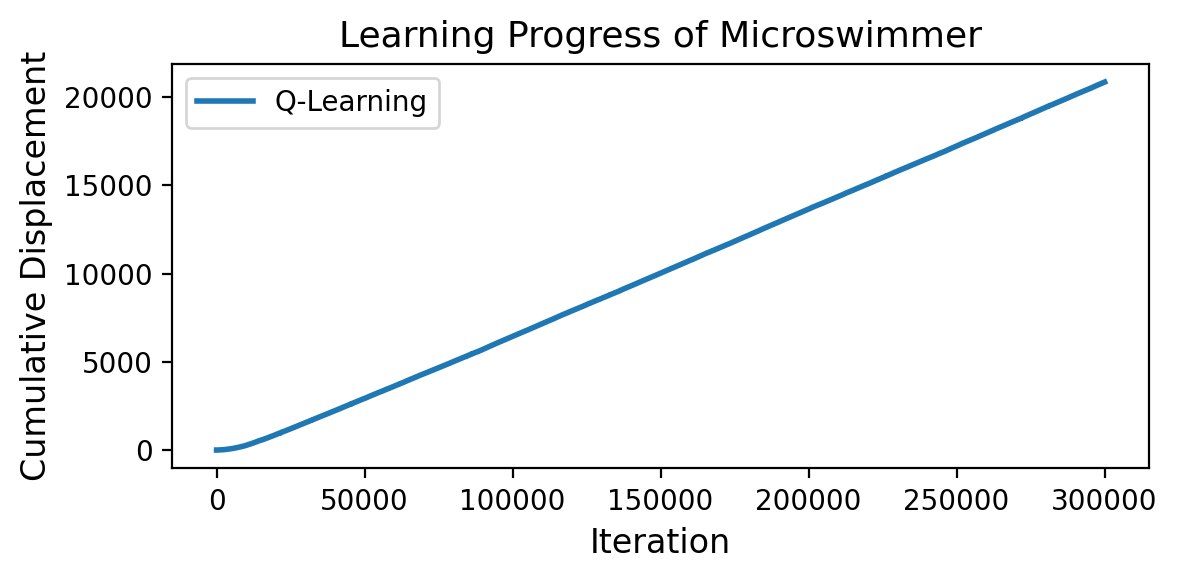

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(disp_history))

plt.figure(figsize=(6,3), dpi=200)

plt.plot(
    x,
    disp_history,
    linewidth=2,
    label="Q-Learning"
)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cumulative Displacement", fontsize=12)

plt.title("Learning Progress of Microswimmer", fontsize=13)

plt.legend()

plt.tight_layout()

plt.show()

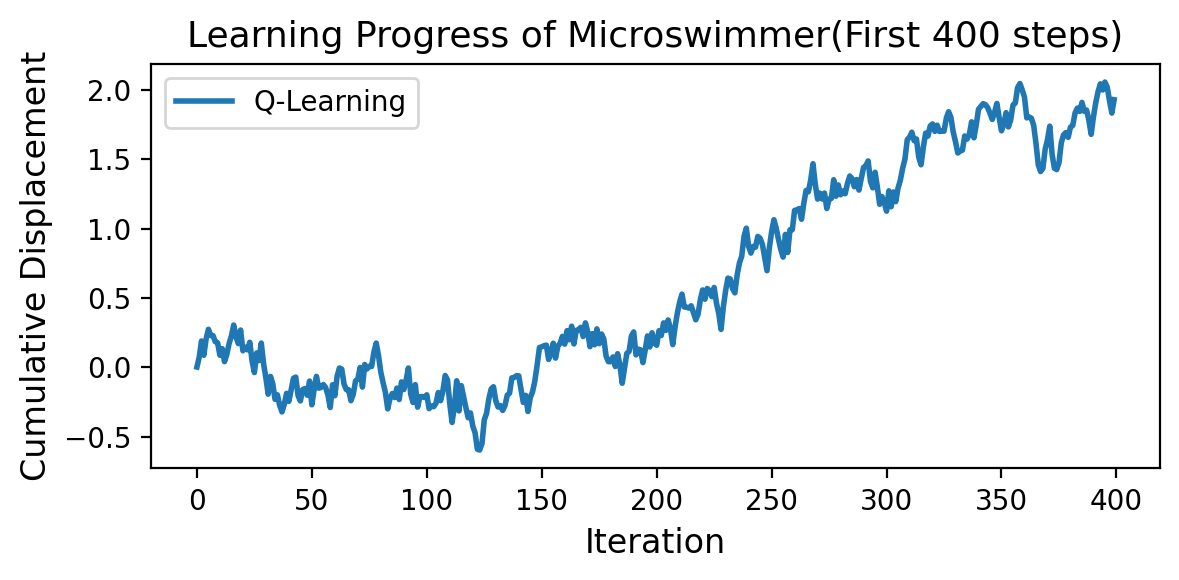

In [17]:
x = np.arange(400)

plt.figure(figsize=(6,3), dpi=200)

plt.plot(
    x,
    disp_history[:400],
    linewidth=2,
    label="Q-Learning"
)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cumulative Displacement", fontsize=12)

plt.title("Learning Progress of Microswimmer(First 400 steps)", fontsize=13)

plt.legend()

plt.tight_layout()

plt.show()

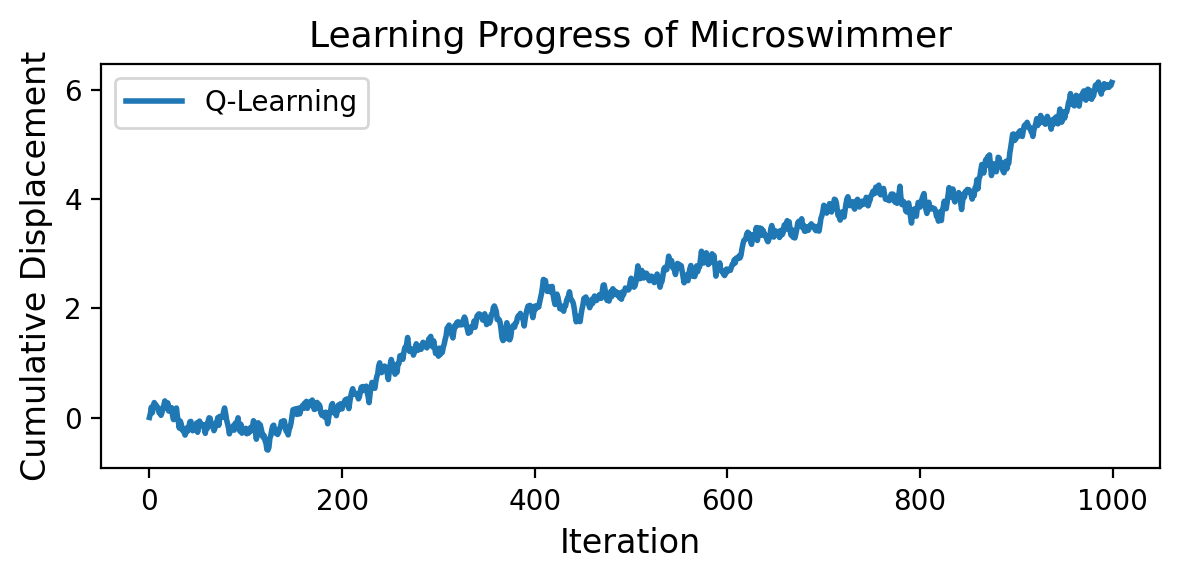

In [18]:
import matplotlib.pyplot as plt
import numpy as np

Num = 1000
x = np.arange(Num)

plt.figure(figsize=(6,3), dpi=200)

plt.plot(
    x,
    disp_history[:Num],
    linewidth=2,
    label="Q-Learning"
)

plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Cumulative Displacement", fontsize=12)

plt.title("Learning Progress of Microswimmer", fontsize=13)

plt.legend()

plt.tight_layout()

plt.show()

In [19]:
# Finding the cycle learned after Q Learning:

In [20]:
policy = np.argmax(q_matrix, axis=1) + 1

print(policy)

[ 1 18 16 16 14 14 14 14 12 12 12 12 12 12 12 12  1 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10  1 18 16 16 14  8  8  8 12  8  8  8 12  8  8  8
  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  8  1 18 16 16  1 14 14 14
 12 12 12 12 12 12 12 12  1 18 16 10 14 10  6 10 10  6  6  6  6  6  6  6
  1 18 16 16 14 14 14 14  1 12  6 12 15  6  6  6  1 18 16 16 15  6  6  6
 13  6  6  6 15  6  6  6  1 18 16 16 14 14 14 14 12 12 12 12 12 12 12 12
  1 18 16 10 10 10 10 10  1 10 10 10 10 10 10 10  1 18 16 16 14 14 14 14
  1 12 12 12 12 12  8  8  1 18 16 16 14  8  8  4 13  8  8  8 15  8  4  8
  1 18 16 16 14 14 14 14  1 12 12 12 12 12 12 12  1 18 16 16 14 14 10 10
  7 18 16 10 15 15  4 10  1 18 16 16  9 14 14 14  9 18 16 12  9 12  4  4
 11 18 16 16 11 18 11  4 13 18 13  4 15  4  4  4  3 18 16 16 14 14 14 14
 12 12 12 12 12 12 12 12  3 18 16 10 10 14 10 10  3 10 10 10 10 10 10 10
  3 18 16 16 14  3 14 14  3 12 12 12 12  8  8 12  3 18 16 16 14 14  8  8
  3  8 13  8 15  8  8  8  3 18 16 16 14 14 14 14  3

In [21]:
for s in range(num_states):

    action = policy[s] - 1

    if q_matrix[s, action] == -np.inf:
        print("INVALID POLICY FOUND")

In [22]:
best_cycle_disp = -float("inf")

best_cycle_states = None
best_cycle_actions = None
best_cycle_next_states = None
best_start_state = None

# Loop through all possible starting states
for start_state in range(1, len(policy) + 1):

    current_state = start_state

    visited_index = {current_state: 0}

    states_history = []
    actions_history = []
    next_states_history = []
    rewards_history = []

    for step in range(100):

        best_action = policy[current_state - 1]

        reward = rewards[current_state][best_action]

        next_state = transition[current_state][best_action]

        states_history.append(current_state)
        actions_history.append(best_action)
        next_states_history.append(next_state)
        rewards_history.append(reward)

        current_state = next_state

        # Cycle detected
        if current_state in visited_index:

            cycle_start = visited_index[current_state]

            cycle_states = states_history[cycle_start:]
            cycle_actions = actions_history[cycle_start:]
            cycle_next_states = next_states_history[cycle_start:]
            cycle_rewards = rewards_history[cycle_start:]

            cycle_disp = sum(cycle_rewards)

            # Store best cycle
            if cycle_disp > best_cycle_disp:

                best_cycle_disp = cycle_disp
                best_cycle_states = cycle_states
                best_cycle_actions = cycle_actions
                best_cycle_next_states = cycle_next_states
                best_start_state = start_state

            break

        visited_index[current_state] = len(states_history)


# Display best cycle
print(f"\nBest starting state = {best_start_state}")
print(f"Best cycle displacement = {best_cycle_disp}\n")

print("Best cycle:\n")

for s, a, ns in zip(
    best_cycle_states,
    best_cycle_actions,
    best_cycle_next_states
):

    reward = rewards[s][a]

    print(
        s,
        "-->",
        a,
        "-->",
        ns,
        "disp =",
        reward
    )


Best starting state = 33
Best cycle displacement = 2.3563521728743857

Best cycle:

481 --> 9 --> 497 disp = 0.19563001755627676
497 --> 11 --> 505 disp = 0.15337049415520299
505 --> 13 --> 509 disp = 0.0971630036137193
509 --> 15 --> 511 disp = 0.03395005496033847
511 --> 17 --> 512 disp = -0.024039372798528413
512 --> 2 --> 256 disp = -0.06252960504488142
256 --> 4 --> 128 disp = 0.0015734674249794577
128 --> 6 --> 64 disp = 0.073005011512397
64 --> 8 --> 32 disp = 0.1385989207009759
32 --> 10 --> 16 disp = 0.19136385353372917
16 --> 12 --> 8 disp = 0.22593649916768016
8 --> 14 --> 4 disp = 0.23685961299321145
4 --> 16 --> 2 disp = 0.21709774723397252
2 --> 18 --> 1 disp = 0.1542950666066362
1 --> 1 --> 257 disp = 0.10666428826018284
257 --> 3 --> 385 disp = 0.18254655959447835
385 --> 5 --> 449 disp = 0.21638802634076565
449 --> 7 --> 481 disp = 0.2184785270632486


In [23]:
# Vizualizations of Learned Policy:

In [24]:
import matplotlib.pyplot as plt
import numpy as np


def get_positions(state):

    """
    state:
    tuple like (6,10,6,10)

    representing arm lengths
    """

    positions = [0]

    for arm_length in state:

        positions.append(
            positions[-1] + arm_length
        )

    return np.array(positions)


def draw_swimmer(ax,
                 state,
                 y=0,
                 xshift=0,
                 label=None):

    """
    state example:
    (6,10,6,10)

    6  -> contracted
    10 -> extended
    """

    positions = [xshift]

    # Visual lengths
    visual_map = {
        6: 4,     # contracted
        10: 10    # extended
    }

    # Colors
    contracted_color = "tab:red"
    extended_color = "tab:blue"

    # Generate sphere positions
    for arm_length in state:

        positions.append(
            positions[-1] + visual_map[arm_length]
        )

    positions = np.array(positions)

    # -------------------------------------------------
    # Draw arms
    # -------------------------------------------------

    for i in range(len(positions)-1):

        arm_length = state[i]

        if arm_length == 10:

            color = extended_color
            lw = 5

        else:

            color = contracted_color
            lw = 3

        ax.plot(
            [positions[i], positions[i+1]],
            [y, y],
            lw=lw,
            color=color
        )

    # -------------------------------------------------
    # Draw spheres
    # -------------------------------------------------

    ax.scatter(
        positions,
        np.full(len(positions), y),
        s=350,
        color="black",
        zorder=3
    )

    # -------------------------------------------------
    # Label
    # -------------------------------------------------

    if label:

        ax.text(
            np.mean(positions),
            y - 3,
            label,
            ha='center',
            fontsize=10
        )

def visualize_transition(current_state_id,
                         action_id,
                         next_state_id):

    current_state = States[current_state_id]
    next_state = States[next_state_id]

    fig, ax = plt.subplots(
        figsize=(12,3),
        dpi=150
    )

    # -------------------------------------------------
    # Current swimmer
    # -------------------------------------------------

    draw_swimmer(
        ax,
        current_state,
        y=0,
        xshift=0,
        label=f"State {current_state_id}"
    )

    # -------------------------------------------------
    # Arrow
    # -------------------------------------------------

    current_length = np.sum(current_state)

    ax.arrow(
        current_length + 5,
        0,
        10,
        0,
        head_width=1,
        length_includes_head=True
    )

    ax.text(
        current_length + 7,
        2,
        f"Action {action_id}"
    )

    # -------------------------------------------------
    # Next swimmer
    # -------------------------------------------------

    draw_swimmer(
        ax,
        next_state,
        y=0,
        xshift=current_length + 25,
        label=f"State {next_state_id}"
    )

    # -------------------------------------------------

    ax.axis('equal')
    ax.axis('off')

    plt.tight_layout()
    plt.show()

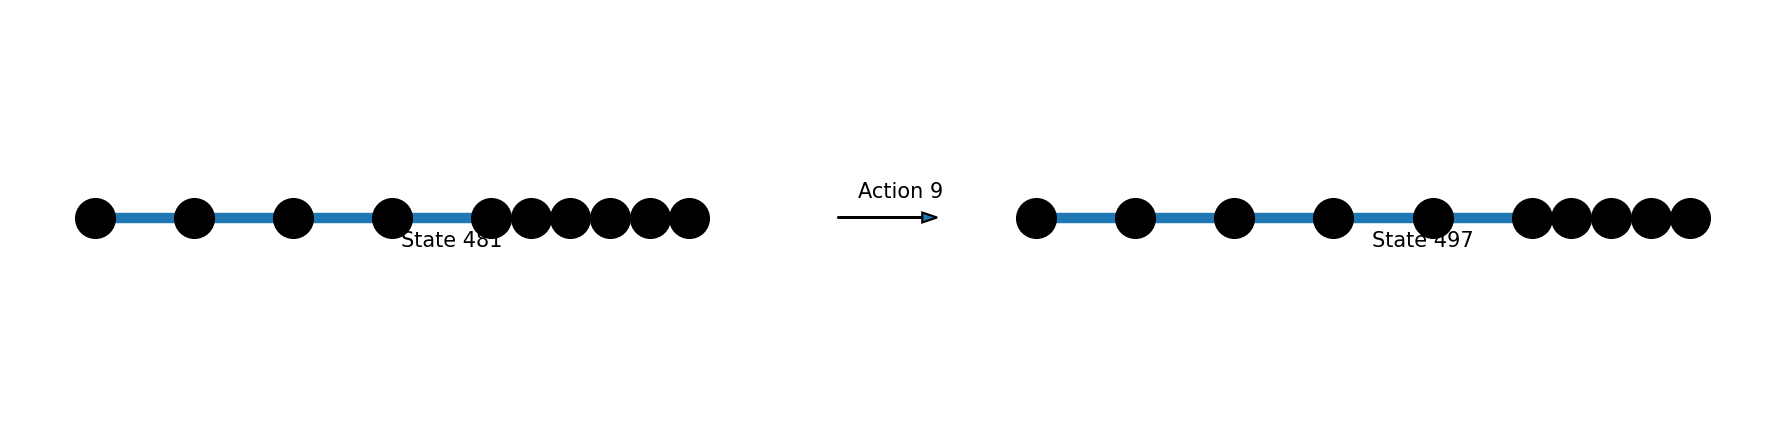

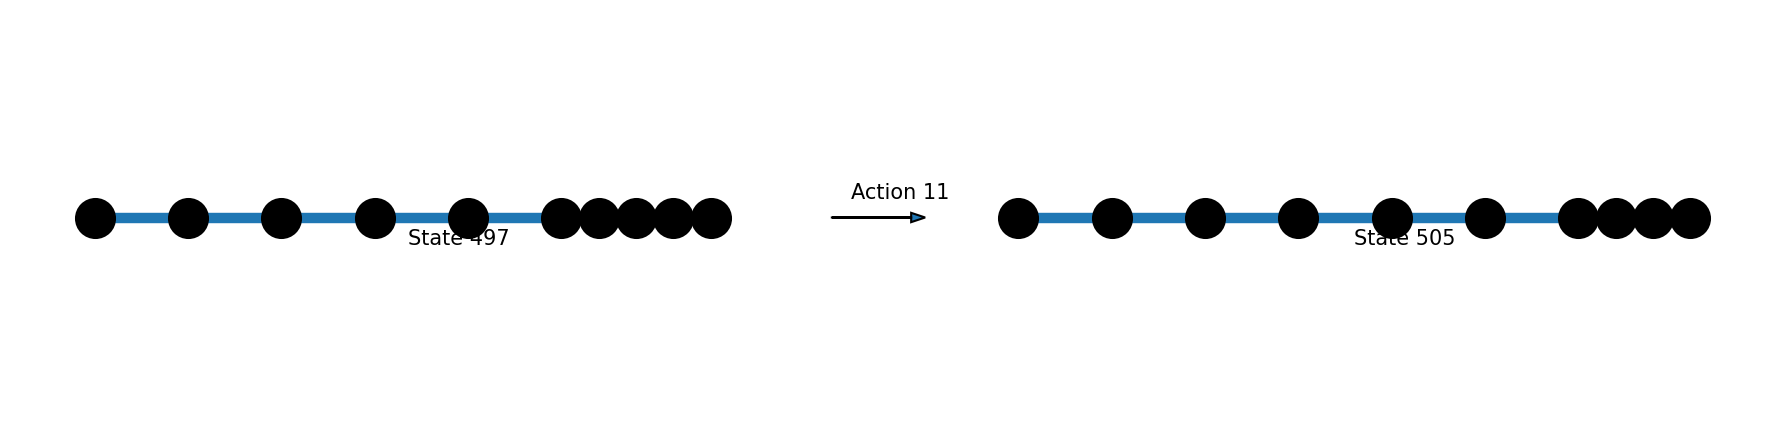

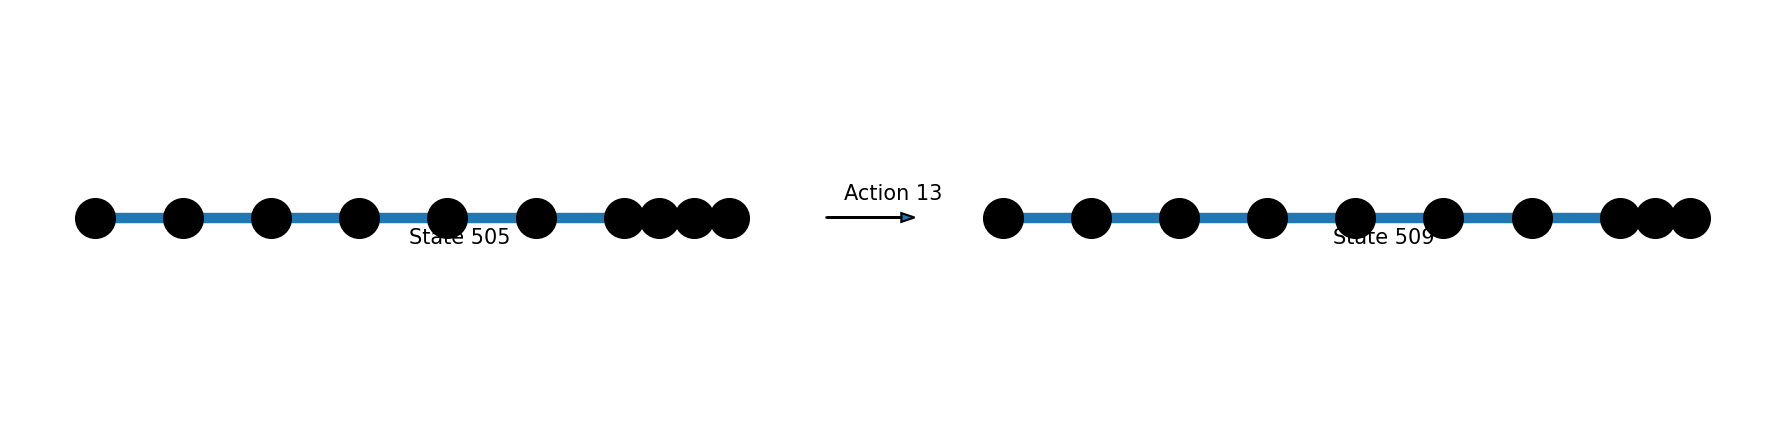

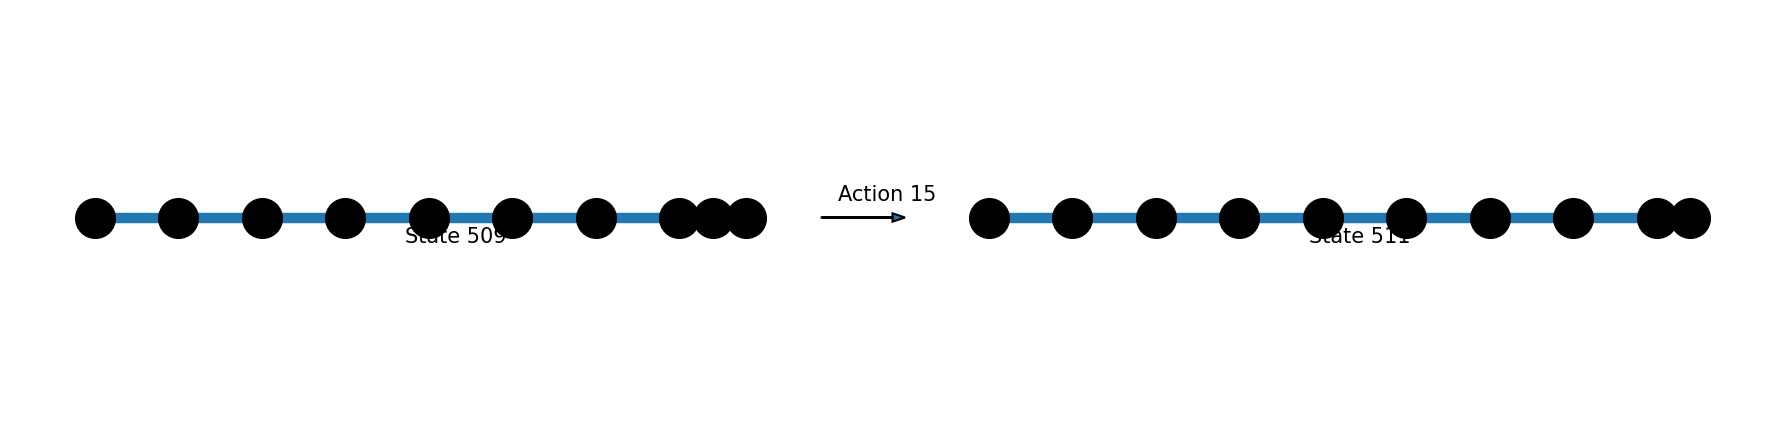

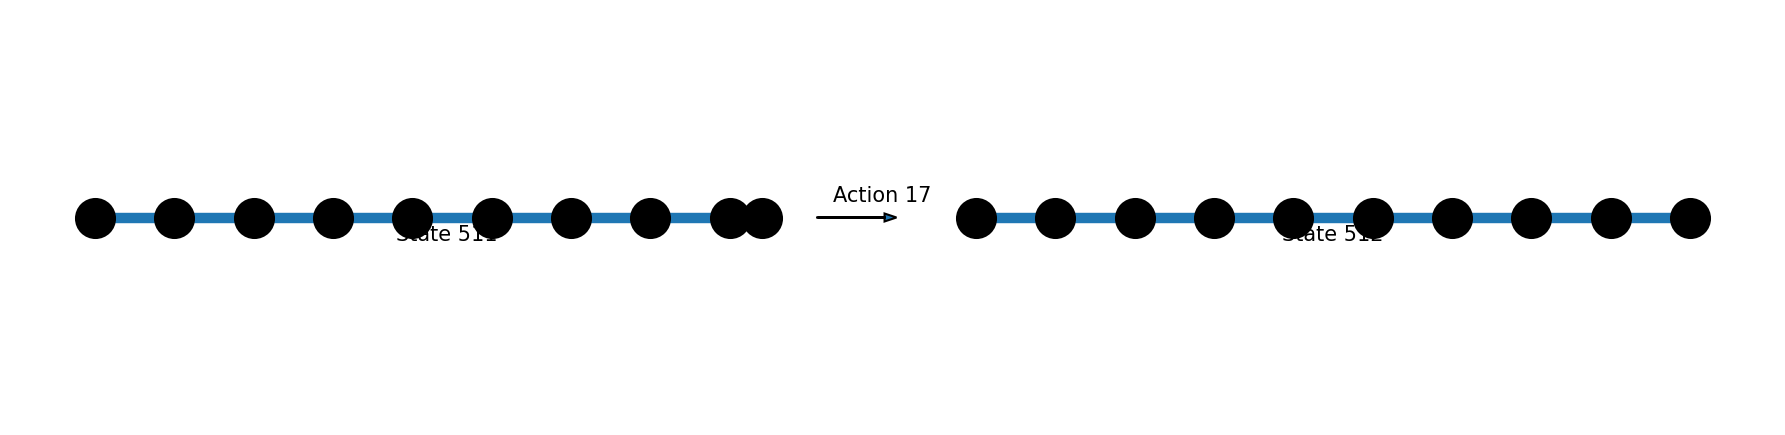

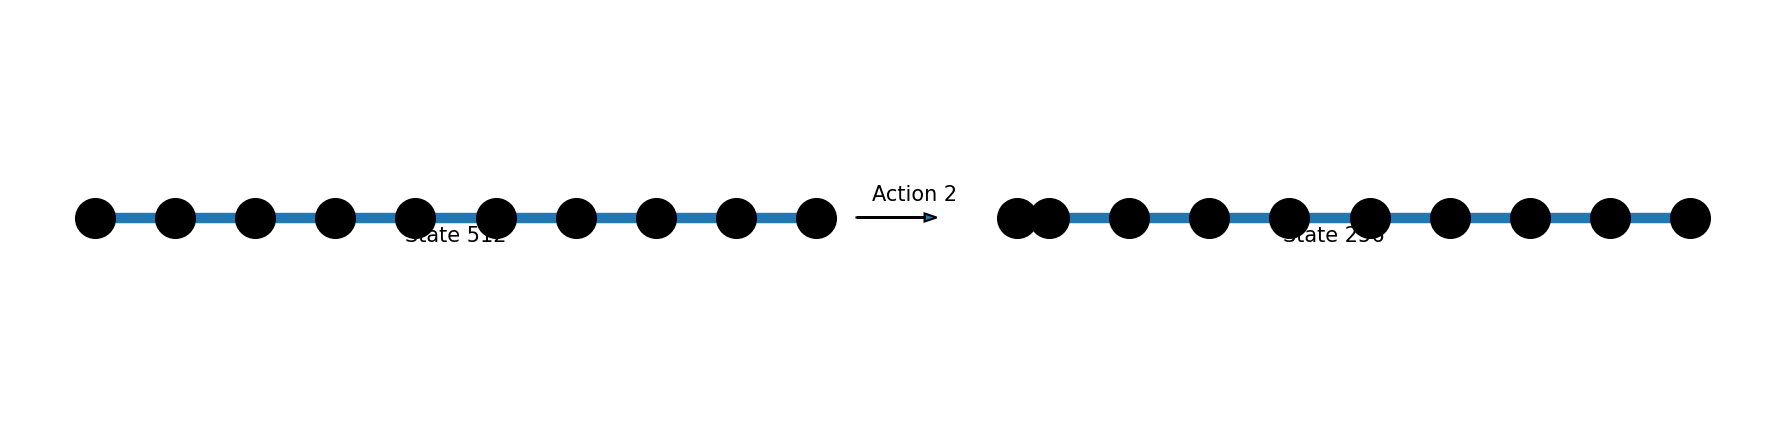

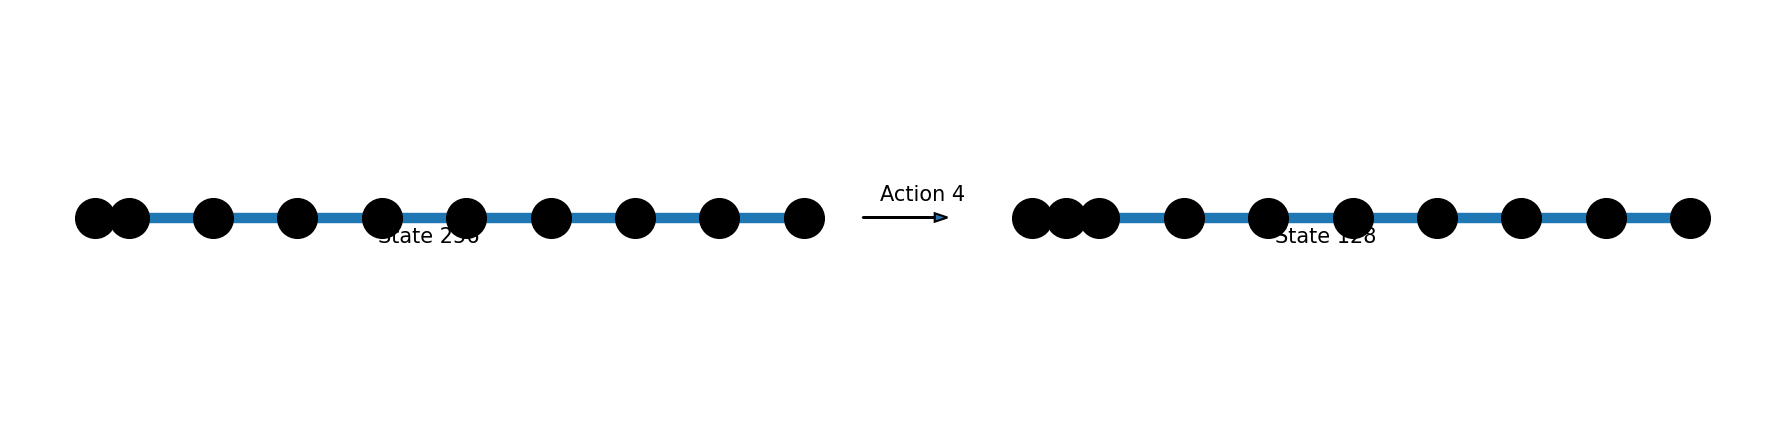

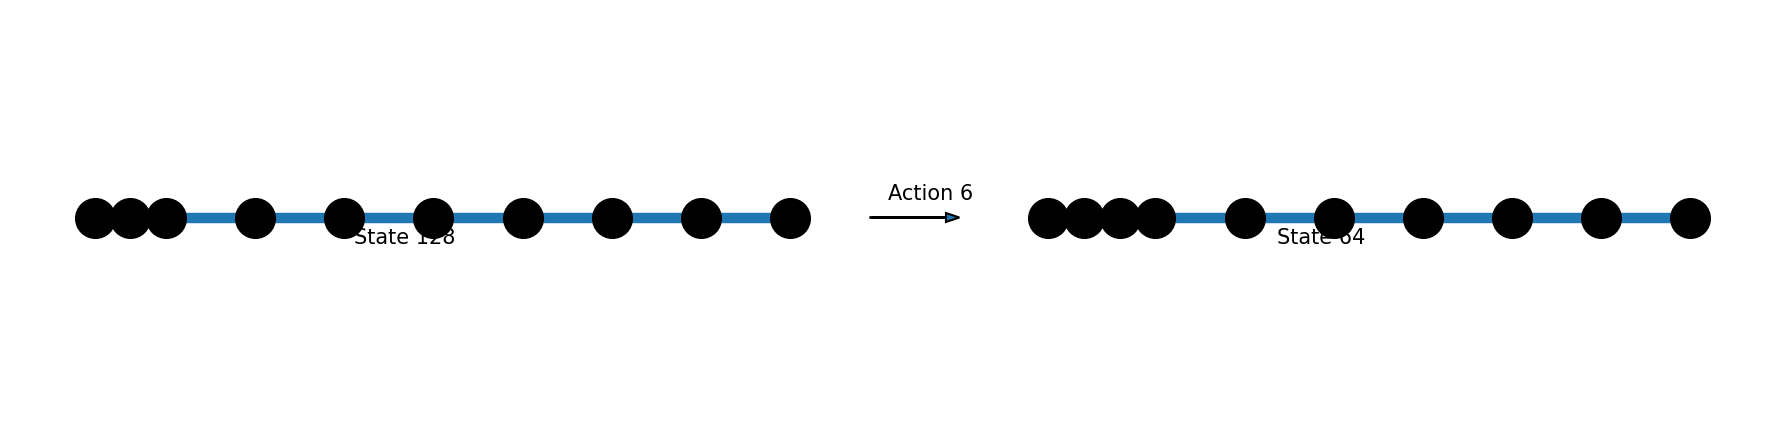

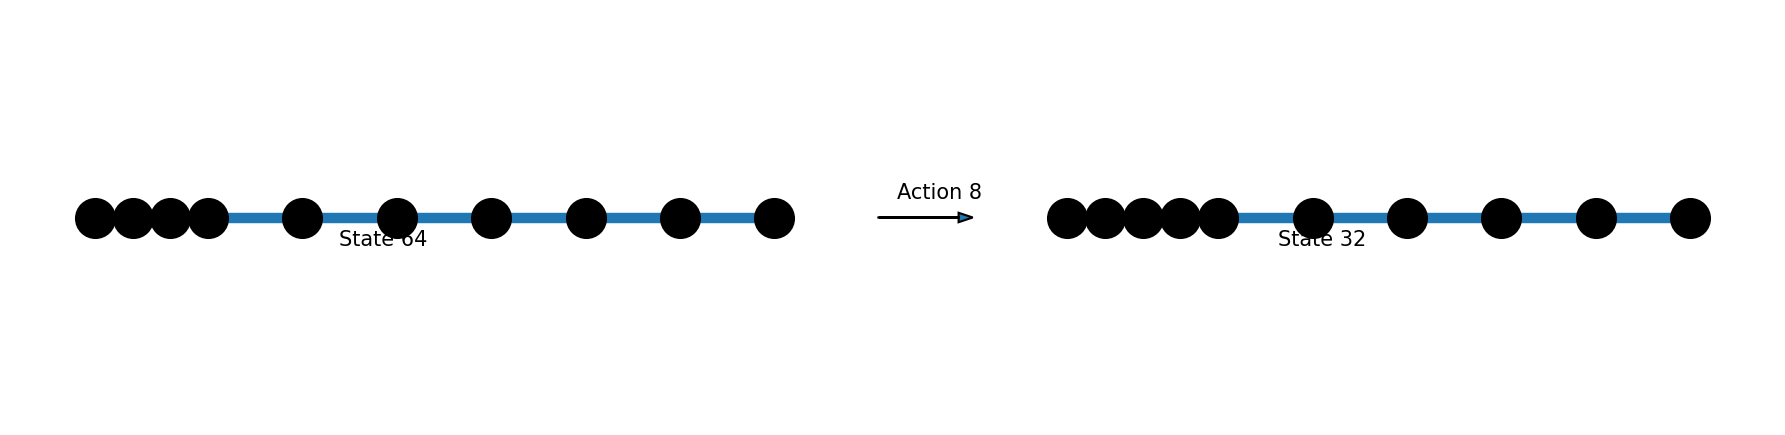

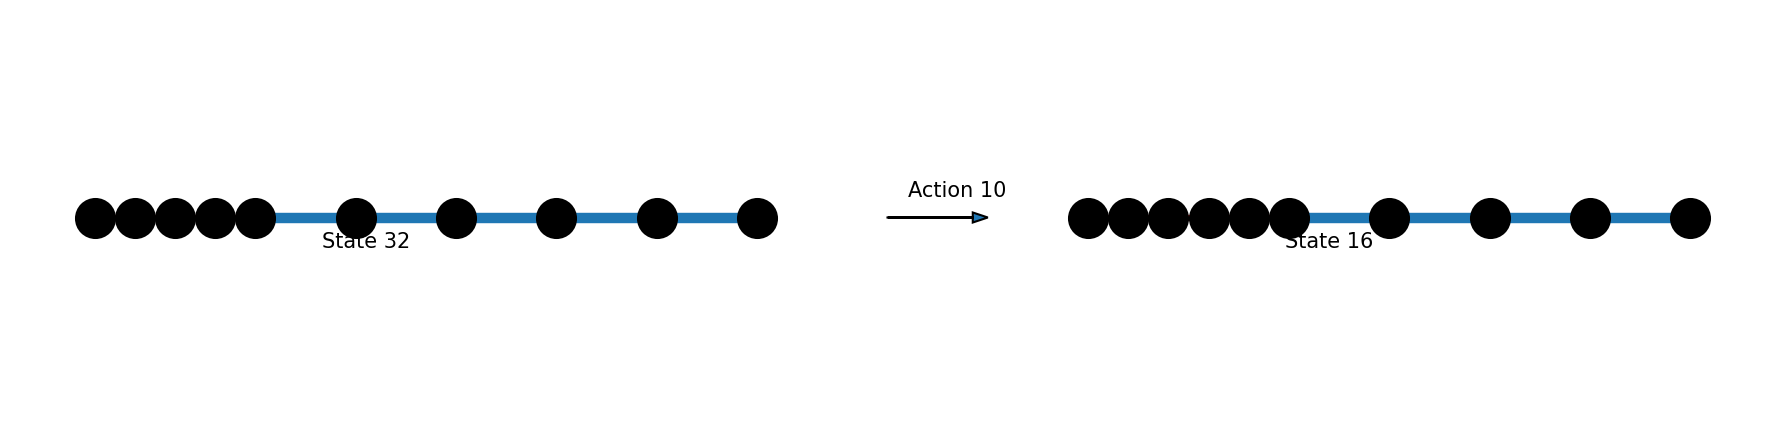

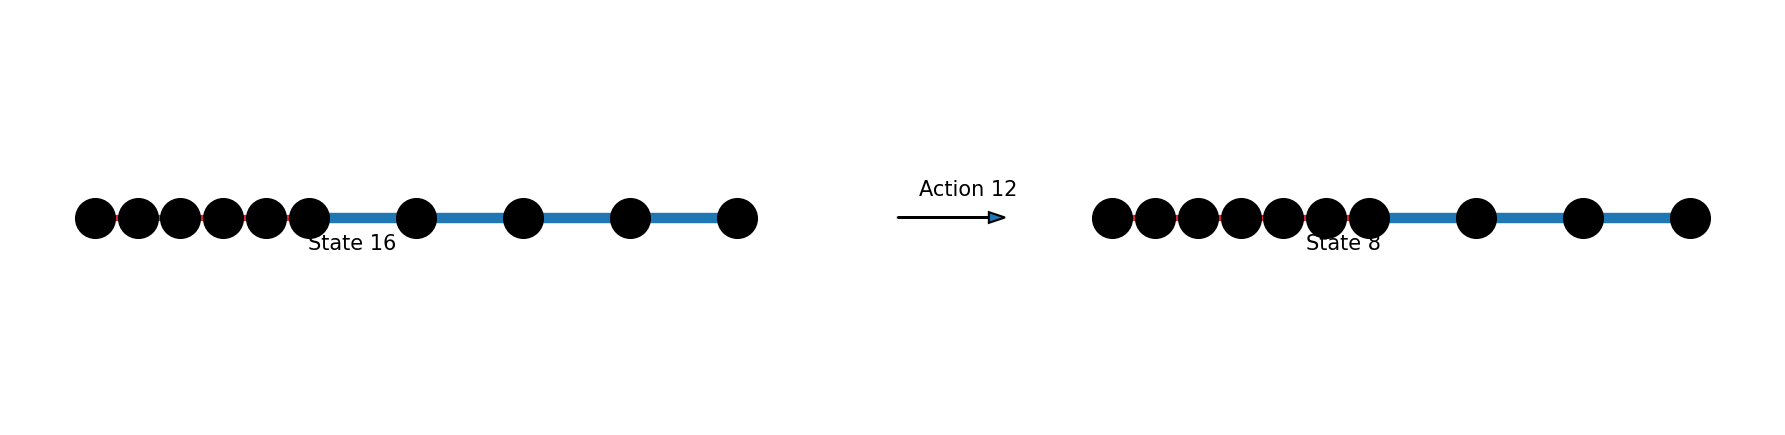

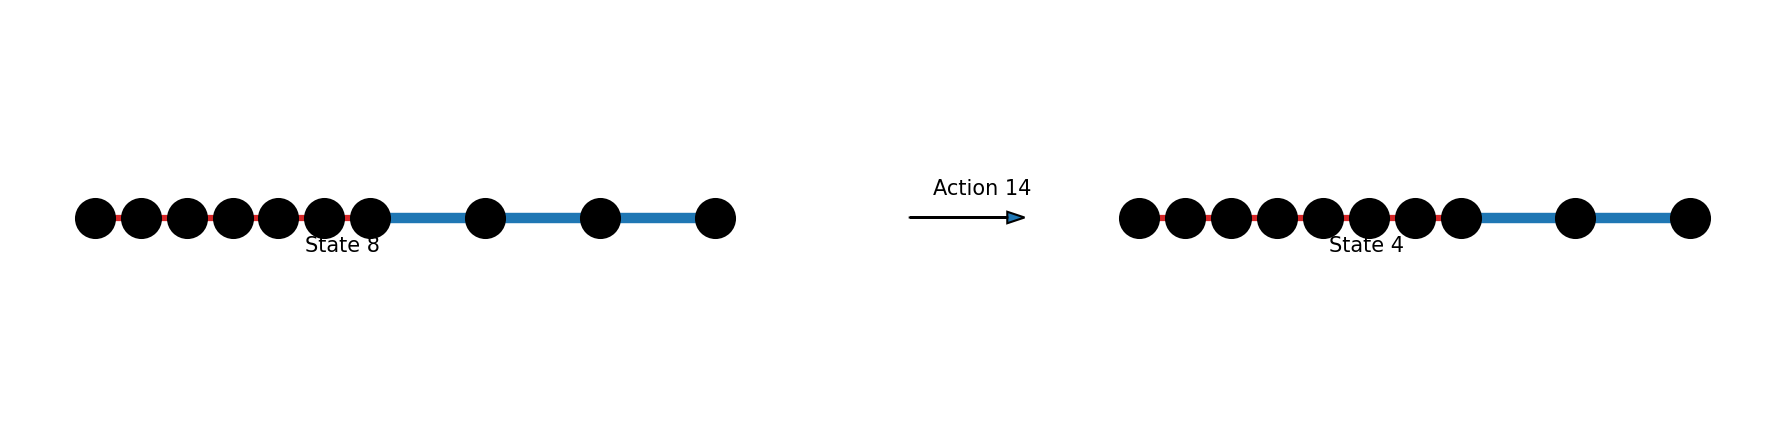

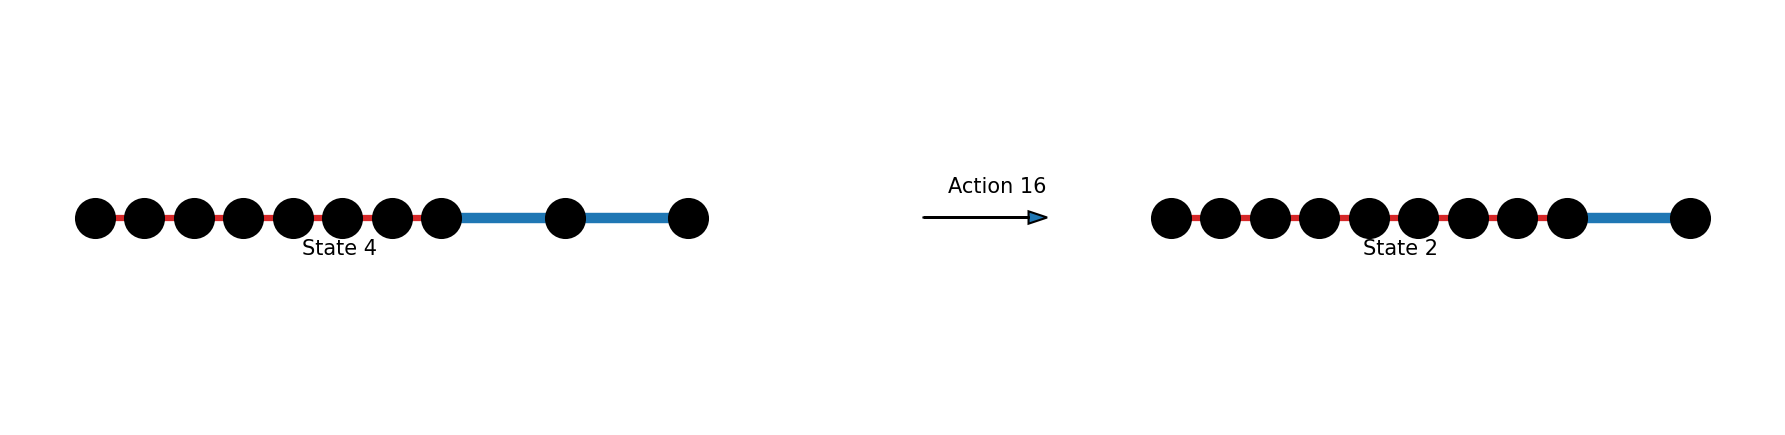

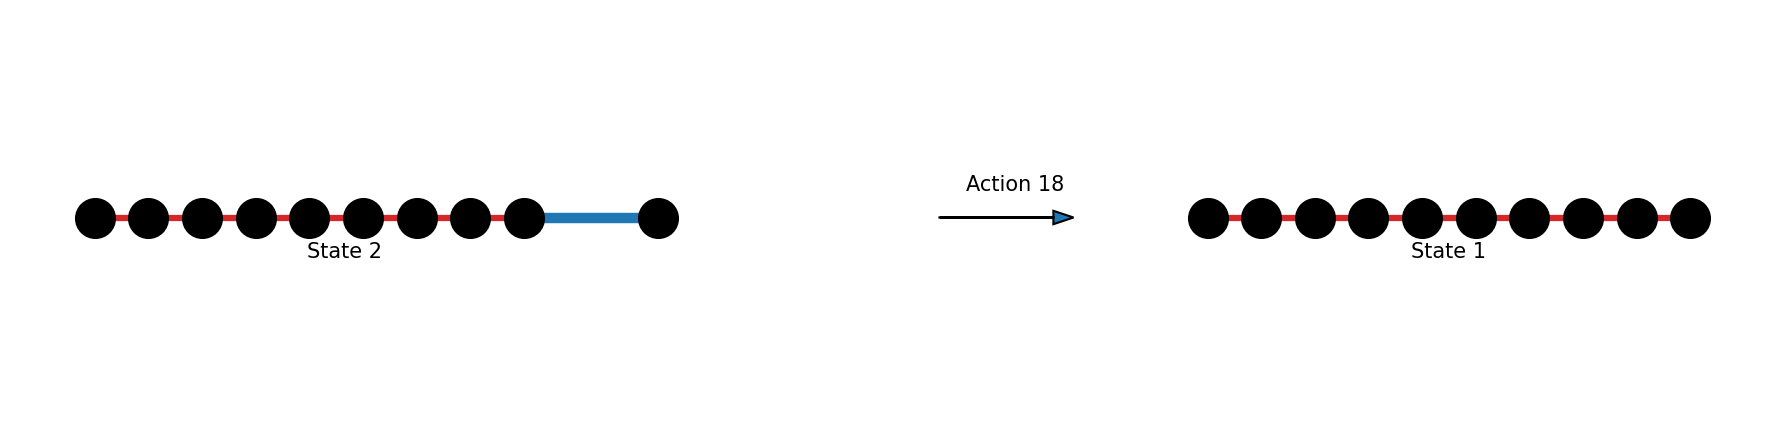

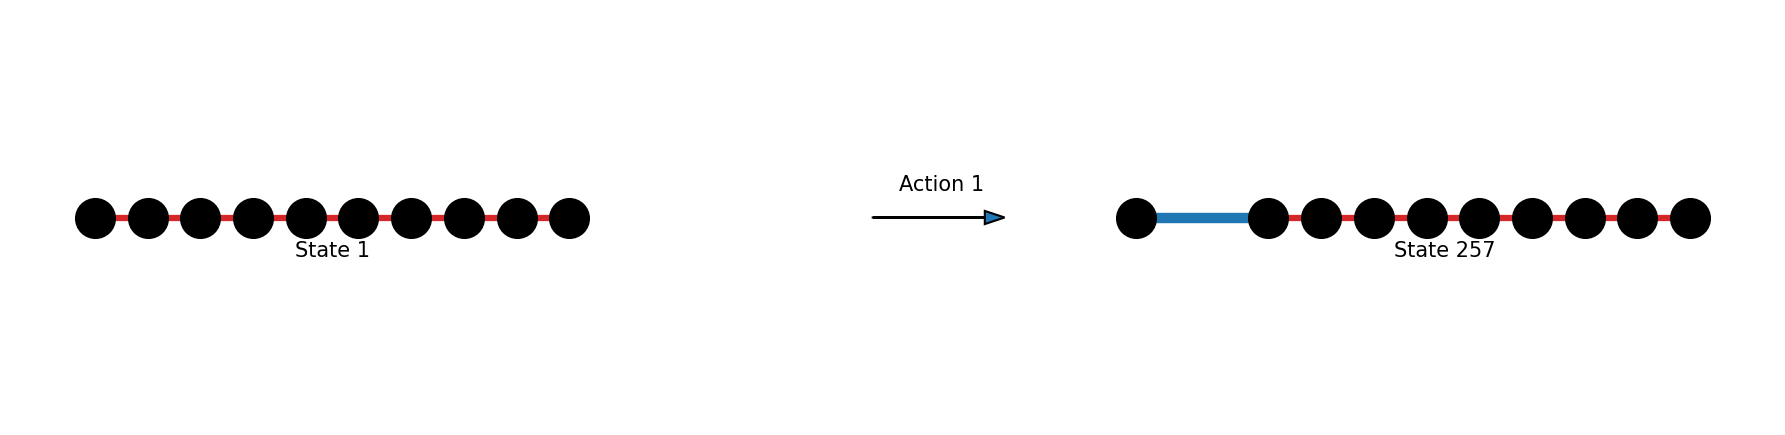

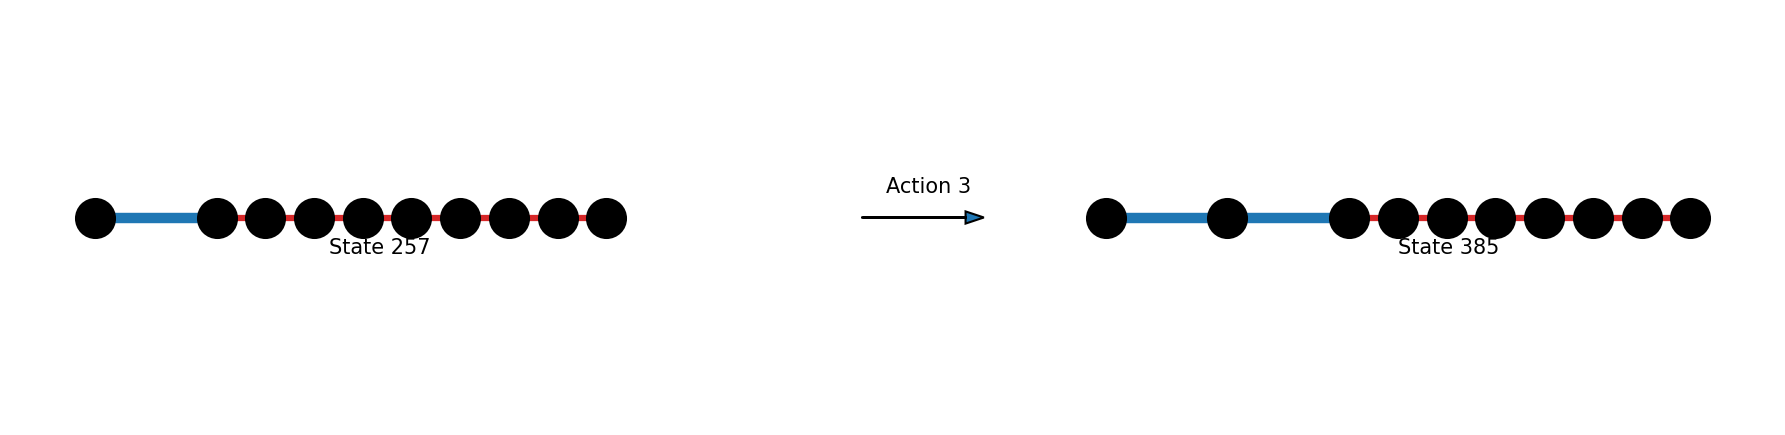

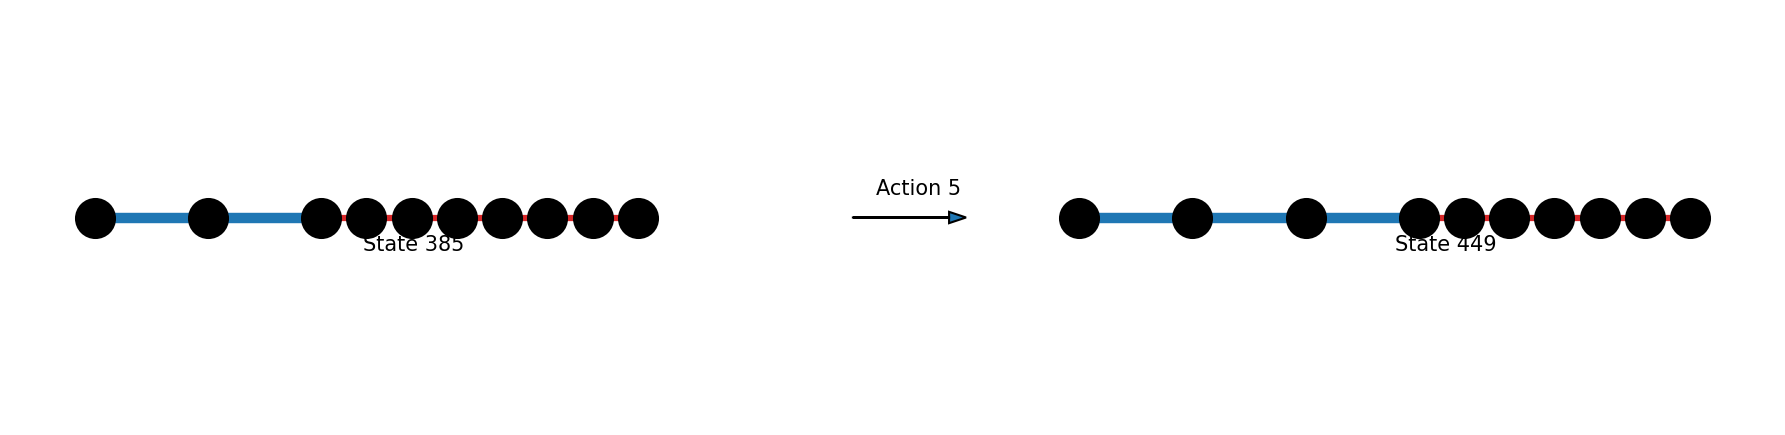

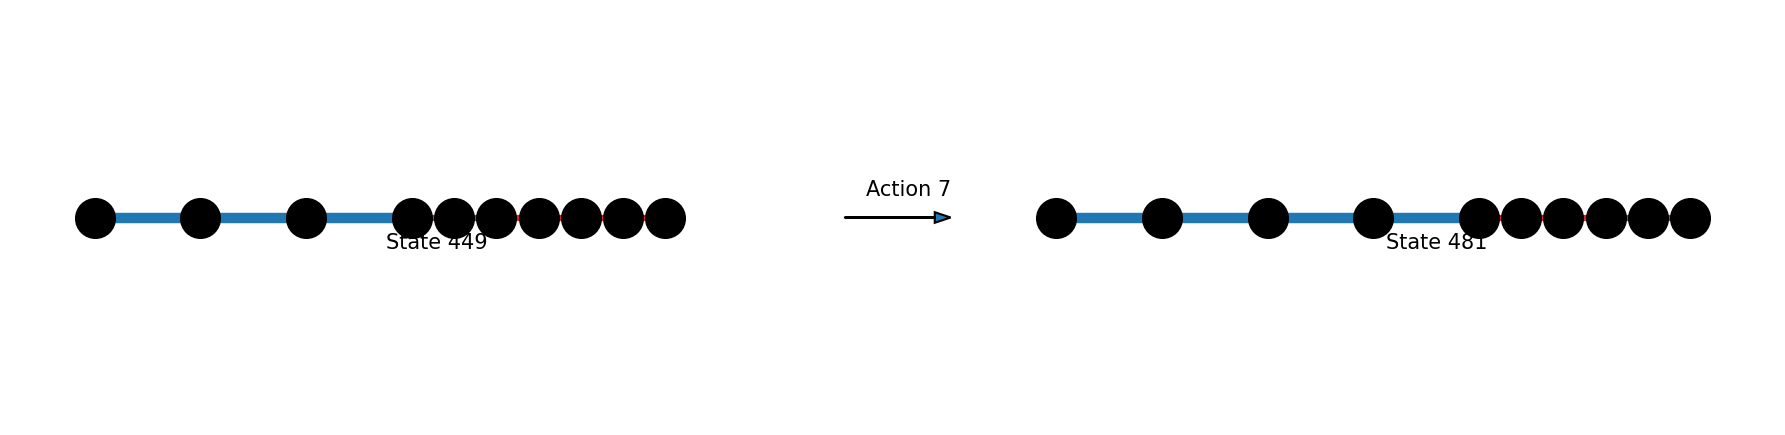

In [25]:
for s, a, ns in zip(
    best_cycle_states,
    best_cycle_actions,
    best_cycle_next_states
):

    visualize_transition(s, a, ns)

In [26]:
best_cycle_disp

np.float64(2.3563521728743857)

In [27]:
# Note sometimes the RL algorithm end up with local optimum solution

In [28]:
# You can clearly see that the RL algorithm end up with longitudinal travelling wave policy which is found to be producing higher net displacement in theory